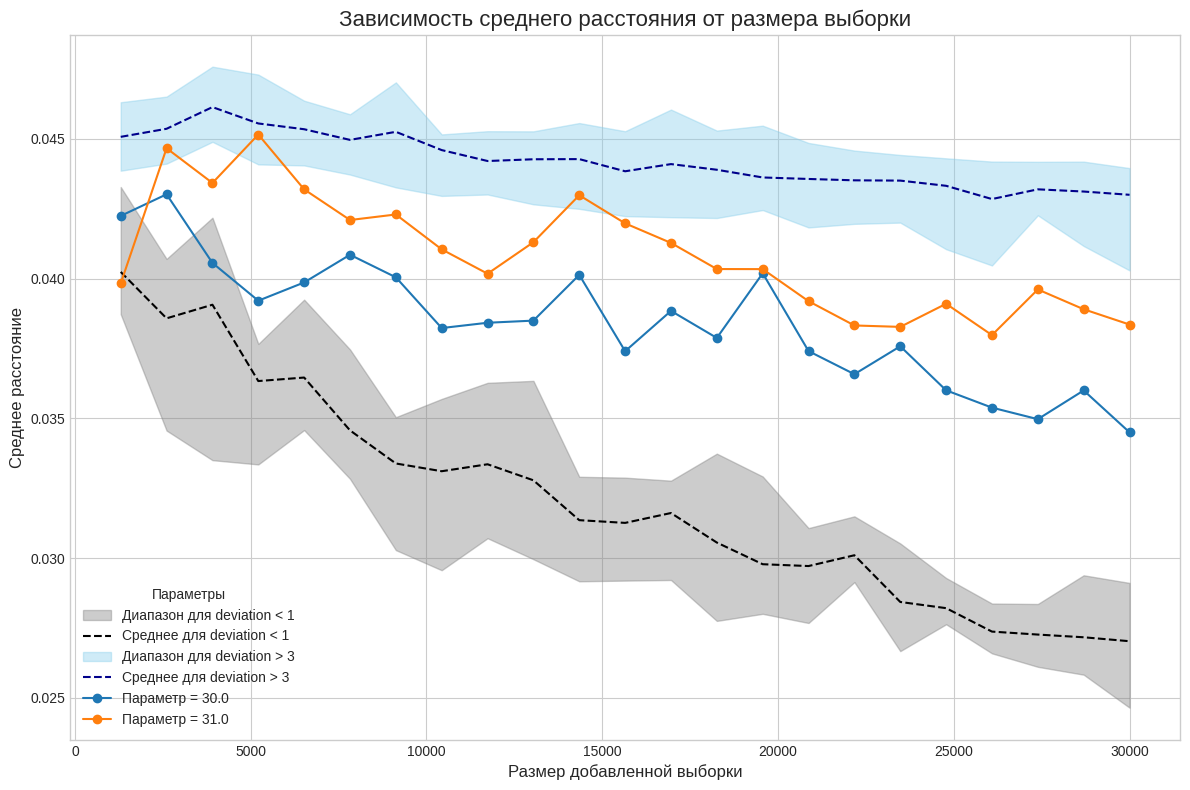

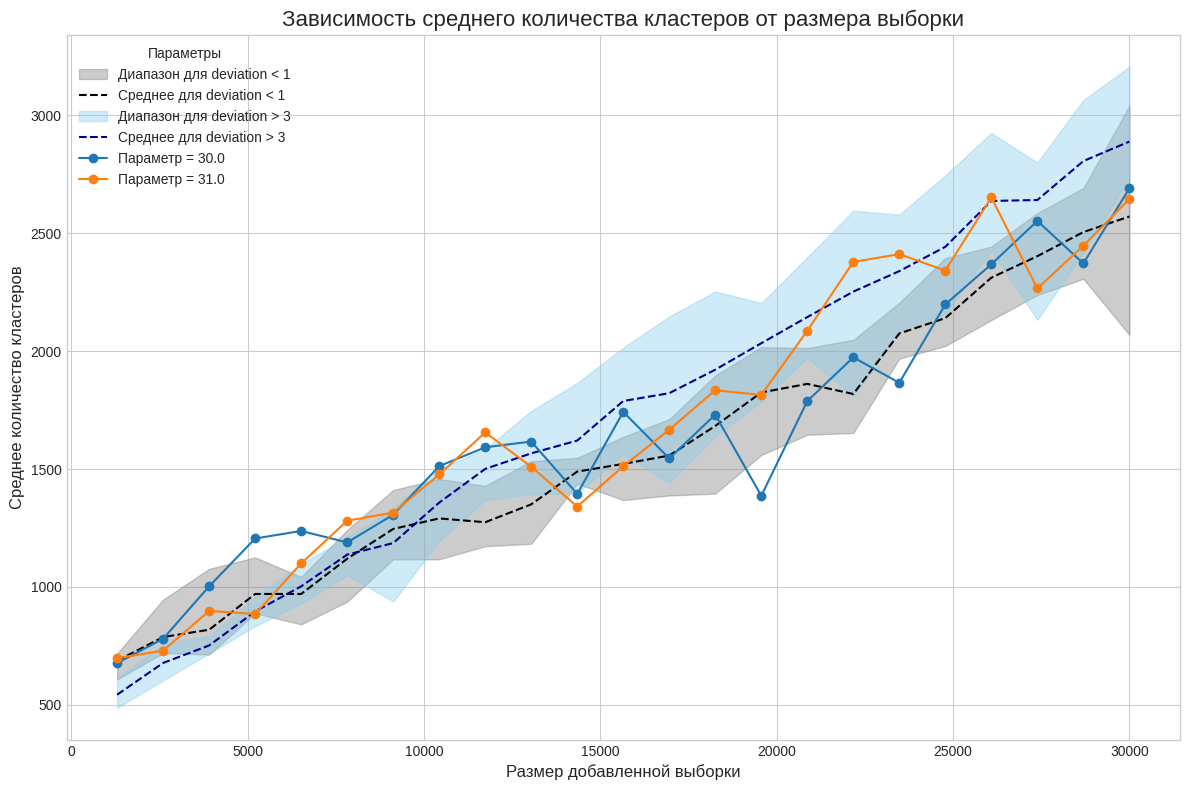

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

def read_timeseries_dataframe(file_path, column_names):
    dataframe = pd.read_csv(file_path, sep=' ', header=None, names=column_names)
    numeric_columns = ['deviation', 'added_size', 'avg_distance', 'avg_clusters_count']
    for column in numeric_columns:
        dataframe[column] = pd.to_numeric(dataframe[column])
    return dataframe

def filter_dataframe_by_added_size(dataframe):
    filtered_dataframe = dataframe[dataframe['added_size'] != 0].copy()
    return filtered_dataframe

def split_dataframe_into_three_groups(dataframe, low_threshold, high_threshold):
    low_range_dataframe = dataframe[dataframe['deviation'] < low_threshold].copy()
    high_range_dataframe = dataframe[dataframe['deviation'] > high_threshold].copy()
    lines_mask = (dataframe['deviation'] >= low_threshold) & (dataframe['deviation'] <= high_threshold)
    lines_dataframe = dataframe[lines_mask].copy()
    return low_range_dataframe, lines_dataframe, high_range_dataframe

def calculate_value_range_by_group(dataframe, group_column, value_column):
    range_summary = dataframe.groupby(group_column)[value_column].agg(['min', 'max']).reset_index()
    sorted_summary = range_summary.sort_values(group_column)
    return sorted_summary

def calculate_value_mean_by_group(dataframe, group_column, value_column):
    mean_summary = dataframe.groupby(group_column)[value_column].mean().reset_index()
    sorted_summary = mean_summary.sort_values(group_column)
    return sorted_summary

def plot_value_range(axes, dataframe, x_column, min_column, max_column, label_text, color_name):
    axes.fill_between(
        dataframe[x_column],
        dataframe[min_column],
        dataframe[max_column],
        color=color_name,
        alpha=0.4,
        label=label_text
    )

def plot_mean_line(axes, dataframe, x_column, y_column, label_text, color_name):
    axes.plot(
        dataframe[x_column],
        dataframe[y_column],
        marker='',
        linestyle='--',
        color=color_name,
        label=label_text
    )

def plot_data_line(axes, dataframe, x_column, y_column, label_text):
    axes.plot(
        dataframe[x_column],
        dataframe[y_column],
        marker='o',
        linestyle='-',
        label=label_text
    )

def plot_multiple_data_lines_by_group(axes, dataframe, group_column, x_column, y_column):
    for group_value, group_dataframe in dataframe.groupby(group_column):
        sorted_group = group_dataframe.sort_values(x_column)
        label_text = f'Параметр = {group_value + 28}'
        plot_data_line(axes, sorted_group, x_column, y_column, label_text)

def configure_plot_appearance(axes, title_text, x_label_text, y_label_text):
    axes.set_title(title_text, fontsize=16)
    axes.set_xlabel(x_label_text, fontsize=12)
    axes.set_ylabel(y_label_text, fontsize=12)
    axes.legend(title='Параметры', fontsize=10)
    axes.grid(True)

def generate_timeseries_plot(dataframe, y_column, title_text, y_label_text, output_filename):
    plt.style.use('seaborn-v0_8-whitegrid')
    figure, axes = plt.subplots(figsize=(12, 8))
    low_range_df, lines_df, high_range_df = split_dataframe_into_three_groups(dataframe, 1, 3)
    if not low_range_df.empty:
        range_summary = calculate_value_range_by_group(low_range_df, 'added_size', y_column)
        mean_summary = calculate_value_mean_by_group(low_range_df, 'added_size', y_column)
        plot_value_range(axes, range_summary, 'added_size', 'min', 'max', 'Диапазон для deviation < 1', 'gray')
        plot_mean_line(axes, mean_summary, 'added_size', y_column, 'Среднее для deviation < 1', 'black')
    if not high_range_df.empty:
        range_summary = calculate_value_range_by_group(high_range_df, 'added_size', y_column)
        mean_summary = calculate_value_mean_by_group(high_range_df, 'added_size', y_column)
        plot_value_range(axes, range_summary, 'added_size', 'min', 'max', 'Диапазон для deviation > 3', 'skyblue')
        plot_mean_line(axes, mean_summary, 'added_size', y_column, 'Среднее для deviation > 3', 'darkblue')
    if not lines_df.empty:
        plot_multiple_data_lines_by_group(axes, lines_df, 'deviation', 'added_size', y_column)
    configure_plot_appearance(axes, title_text, 'Размер добавленной выборки', y_label_text)
    figure.tight_layout()
    plt.savefig(output_filename)

def main():
    file_path = 'x.txt'
    column_names = ['deviation', 'prediction_size', 'added_size', 'experiment',
                    'base_size', 'avg_distance', 'avg_clusters_count']
    full_dataframe = read_timeseries_dataframe(file_path, column_names)
    processed_dataframe = filter_dataframe_by_added_size(full_dataframe)
    generate_timeseries_plot(
        processed_dataframe,
        'avg_distance',
        'Зависимость среднего расстояния от размера выборки',
        'Среднее расстояние',
        'plot_avg_distance.png'
    )
    generate_timeseries_plot(
        processed_dataframe,
        'avg_clusters_count',
        'Зависимость среднего количества кластеров от размера выборки',
        'Среднее количество кластеров',
        'plot_avg_clusters_count.png'
    )
    plt.show()

main()